# Processing Puromycin Data

____

In [23]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import inhibitors as INH
# Add repo root to path for utilities
import sys
repo_root = Path().resolve().parents[1]  # Inhibitors -> notebooks -> cof_paper
sys.path.insert(0, str(repo_root))
import utilities as ld


## Data Configuration
___

In [24]:
# ── Data Path ─────────────────────────────────────────────
#data_dir = Path(r'/Volumes/Luis_DRIVE/CoF Manuscript LIFs/Fig 1_Puro LIF Files/Analysis_LA')
data_dir = Path(r'E:/Co-translational folding (CoF) paper/Fig 4_puro_fast')

list_folder_substrings, list_names = ld.get_folder_substrings_and_names(
    data_dir,
    process_individual_days=False,
)
print(list_folder_substrings)
print(list_names)


Found 2 plasmids in 25 folders
  pRS038: 1 experiment(s)
  pRS048: 1 experiment(s)
['pRS038', 'pRS048']
['4sfGFP-2mCh-Xbp1', 'Xbp1-4sfGFP-2mCh']


## Processing & Plotting Configuration
___

In [28]:
# ── Processing Parameters ─────────────────────────────────
inhibitor_frame_index = 4  # 0-indexed: frame when treatment was applied
frame_interval_sec = 20
use_sem = True
show_summary = False
show_individual_trajectories = False
max_percentage_threshold_after_treatment = None
normalization_method = None  # options: 'mean', 'minmax', 'percentile', None
percentile_range = None      # only used with normalization_method='percentile'
treatment_label = 'Puromycin'

# ── What to Report ────────────────────────────────────────
report_spots = True  # True = number of spots; False = intensity

# ── Plotting Parameters ───────────────────────────────────
figsize = (6, 4.5)
ylims = (-20, 800) if not report_spots else (-0.02, 1.1)
xlims = (-1.5, 15)
show_runoff_time = False
show_treatment_line = False
threshold_percentage_for_runoff = 0.1
results_folder = Path('E:/Co-translational folding (CoF) paper/Fig 4_puro_fast')  # Set to a Path to save plots


## Plasmid Substrings
___

In [29]:
substring_1 = 'pRS038'
substring_2 = 'pRS048'



## Processing & Plotting
___

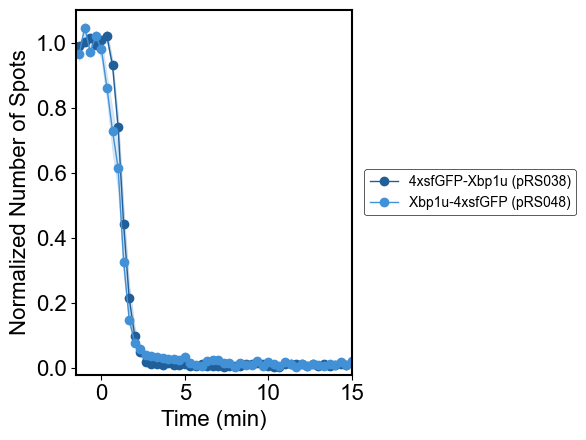

[None, None]

In [30]:
selected_field = 'spot_int_ch_1'

# ── Process both plasmids ────────────────────────────
process_kwargs = dict(
    data_dir=data_dir,
    inhibitor_frame_index=inhibitor_frame_index,
    selected_field=selected_field,
    use_sem=use_sem,
    show_summary=show_summary,
    max_percentage_threshold_after_treatment=max_percentage_threshold_after_treatment,
    frame_interval_sec=frame_interval_sec,
    normalization_method=normalization_method,
    percentile_range=percentile_range,
)

responding_indices_1, frames_1, intensities_1, spots_per_frame_1, _, _, _, _ = INH.process_inhibitor_data(
    substring_in_data_dir=substring_1, **process_kwargs,
)
responding_indices_2, frames_2, intensities_2, spots_per_frame_2, _, _, _, _ = INH.process_inhibitor_data(
    substring_in_data_dir=substring_2, **process_kwargs,
)


# ── Select data to plot ───────────────────────────────────
if report_spots:
    data_1, data_2 = spots_per_frame_1, spots_per_frame_2
    y_label = 'Normalized Number of Spots'
else:
    data_1, data_2 = intensities_1, intensities_2
    y_label = 'Norm. Intensity' if normalization_method else 'Intensity'

# ── Plot ──────────────────────────────────────────────────
INH.plot_multiple_inhibitors(
    full_frames_list=[frames_1, frames_2],
    intensities_normalized_list=[data_1, data_2],
    inhibitor_frame_index=inhibitor_frame_index,
    legend_labels=['4xsfGFP-Xbp1u (pRS038)', 'Xbp1u-4xsfGFP (pRS048)'],
    colors=['#215F9A', '#4290D6'], #215F9A (xbp1u), #1B4F7F (darker), #4290D6 (lighter), #8E9E8F (sfGFP), #929000 (GFPuv)
    figsize=figsize,
    plot_name='Fig 4_Puro_fast_NC int',
    use_sem=use_sem,
    show_individual_trajectories=show_individual_trajectories,
    show_runoff_time=show_runoff_time,
    #threshold_percentage_for_runoff=threshold_percentage_for_runoff,
    ylims=ylims,
    xlims=xlims,
    show_treatment_line=show_treatment_line,
    y_label=y_label,
    treatment_label=treatment_label,
    results_folder=results_folder,  
)
